# **Library Selection & Data Loading**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/Climate_change_Emissions_indicators_E_All_Data_(Normalized).csv")

# **Handling Missing Values**

In [ ]:
for col in df.columns:
    if df[col].dtype in ['float64', 'int64']:
        df[col] = df[col].fillna(df[col].mean())
    else:
        df[col] = df[col].fillna(df[col].mode()[0])

# **Data Type Correction**

In [ ]:
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df['Value'] = pd.to_numeric(df['Value'], errors='coerce')
df.columns = df.columns.str.strip()

# **Top 10 Emitters Analysis**

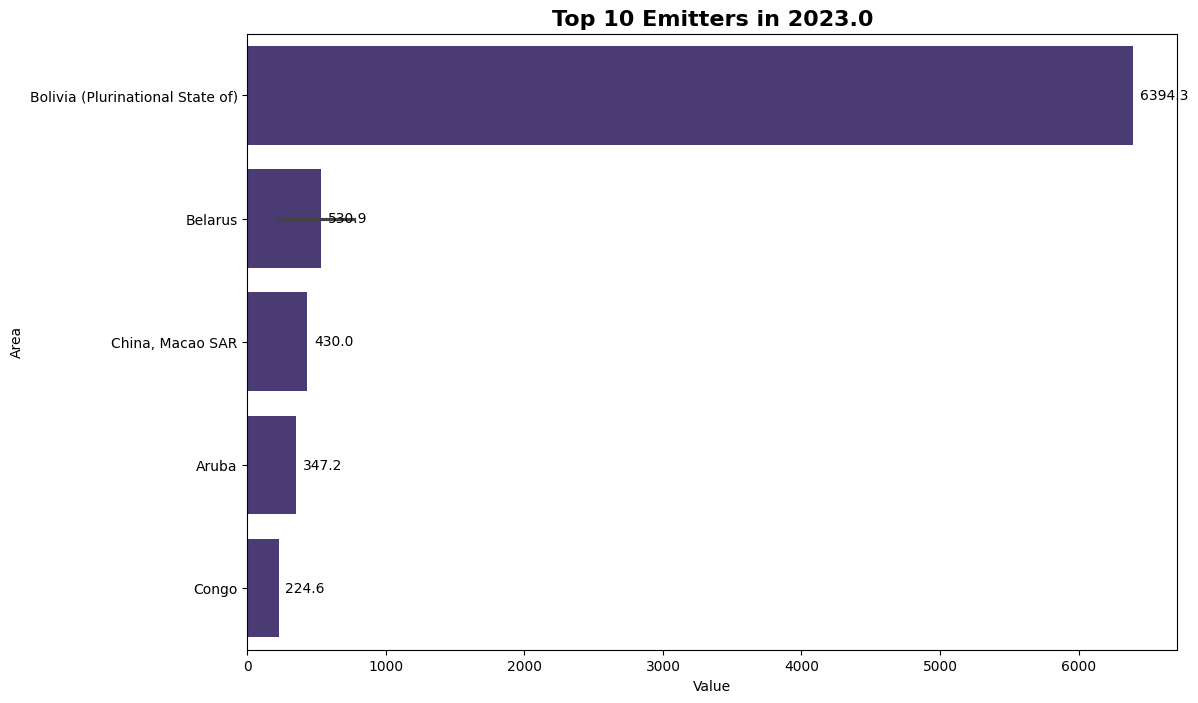

In [ ]:
latest_year = df['Year'].max()
top_10 = df[df['Year'] == latest_year].nlargest(10, 'Value')

plt.figure(figsize=(12, 8))
sns.set_palette("viridis")
plot = sns.barplot(data=top_10, x='Value', y='Area')

for i in plot.containers:
    plot.bar_label(i, fmt='%.1f', padding=5)

plt.title(f'Top 10 Emitters in {latest_year}', fontsize=16, fontweight='bold')
plt.show()

# **Emissions Trends & Grouping**

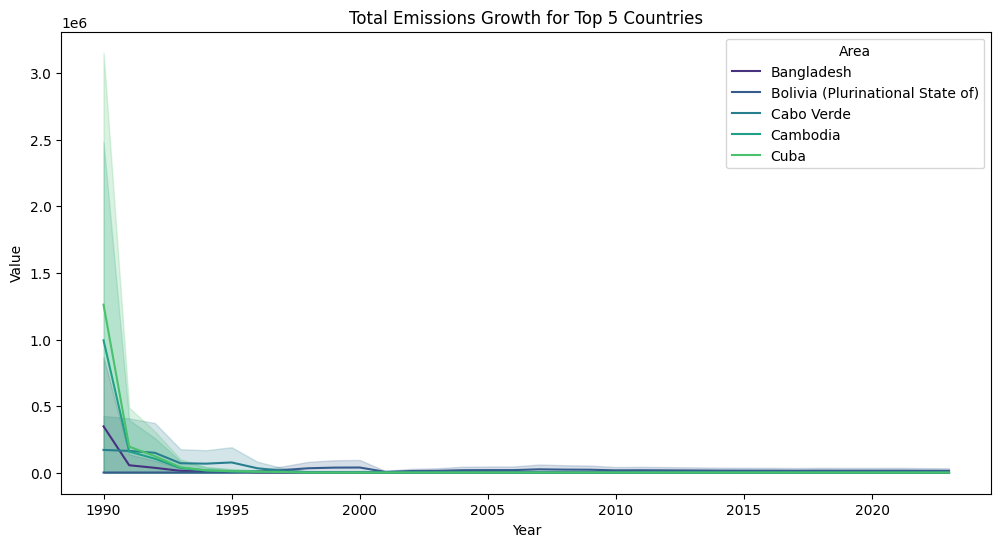

In [ ]:
top_countries = df.groupby('Area')['Value'].sum().nlargest(5).index
df_trends = df[df['Area'].isin(top_countries)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_trends, x='Year', y='Value', hue='Area', estimator='sum')
plt.title('Total Emissions Growth for Top 5 Countries')
plt.show()

df['Contribution_Level'] = pd.qcut(df['Value'], q=4, labels=['Bronze', 'Silver', 'Gold', 'Platinum'])

# **Correlation Matrix**

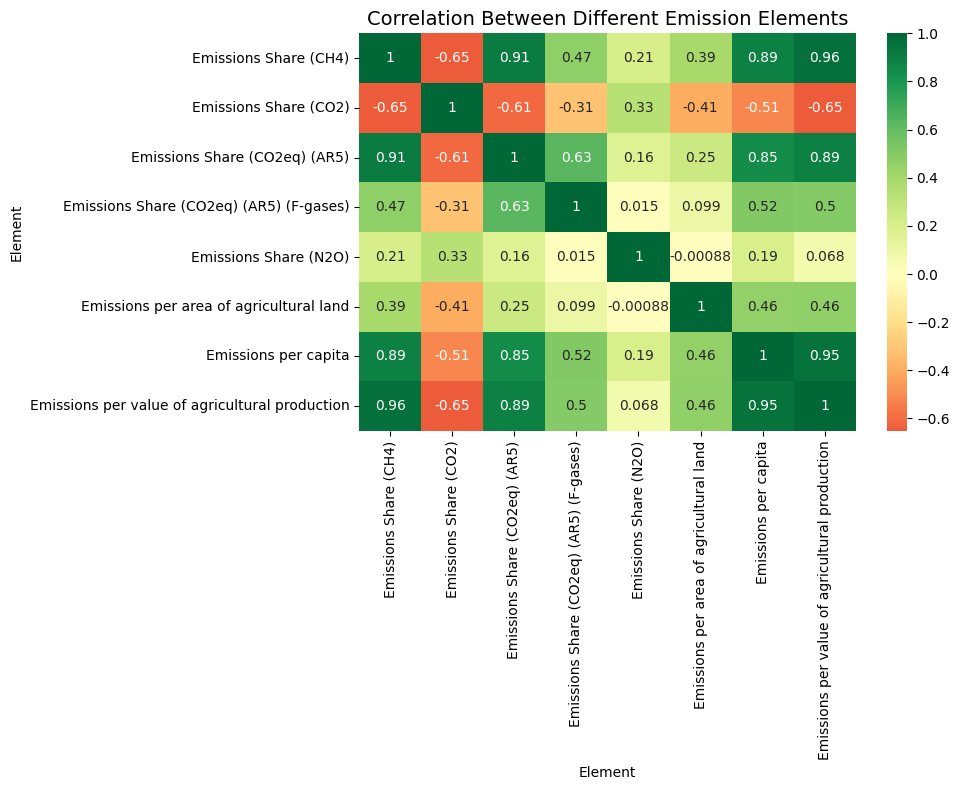

In [ ]:
pivot_corr = df.pivot_table(index='Year', columns='Element', values='Value').corr()

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_corr, annot=True, cmap='RdYlGn', center=0)
plt.title('Correlation Between Different Emission Elements', fontsize=14)
plt.tight_layout()
plt.show()

# **Historical Emission Gap Analysis**

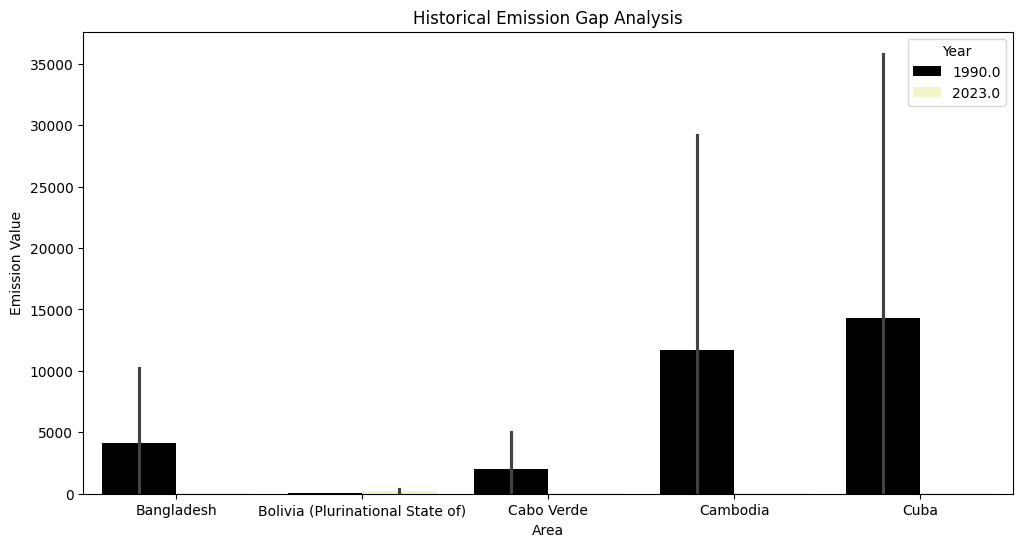

In [ ]:
top_5_areas = df.groupby('Area')['Value'].sum().nlargest(5).index
df_compare = df[df['Area'].isin(top_5_areas)]

first_year = df_compare['Year'].min()
last_year = df_compare['Year'].max()
df_filtered = df_compare[df_compare['Year'].isin([first_year, last_year])]

plt.figure(figsize=(12, 6))
sns.barplot(data=df_filtered, x='Area', y='Value', hue='Year', palette='magma')

plt.title('Historical Emission Gap Analysis')
plt.ylabel('Emission Value')
plt.legend(title='Year')
plt.show()

# **Data Export and Download**

In [ ]:
df.to_csv('Climate_Change_Final_Analysis.csv', index=False)